# NB14: ASMA PA Isolate Virulence Profiling & Phylogenetic Context

**Project**: CF Protective Microbiome Formulation Design
**Goal**: Profile every PROTECT PA isolate for virulence systems (T3SS, biofilm,
regulatory), compare against PAO1/PA14 reference models, and build a gene-content
phylogenetic tree placing PROTECT isolates in the context of lung/airway PA diversity.

## Approach
1. Query all virulence genes for each of 651 PROTECT PA genomes
2. Classify each as PAO1-like, PA14-like, or intermediate
3. Sample ~150 lung/airway PA from pangenome + reference strains
4. Build gene cluster presence/absence matrix → Jaccard distance → NJ tree
5. Annotate circular tree with virulence features, patient data, isolation source

**Requires**: BERDL Spark access + pycirclize

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, to_tree
from Bio import Phylo
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data')
FIGS = Path('/home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

PA_CLADE = 's__Pseudomonas_aeruginosa--RS_GCF_001457615.1'

# Reference strain accessions (pangenome genome IDs)
PAO1_ID = 'RS_GCF_000006765.1'  # PAO1 reference
PA14_ID = 'RS_GCF_000014625.1'  # PA14 reference (UCBPP-PA14)

print('Setup complete')

Setup complete


## 1. Per-ASMA Isolate Virulence Profiling

Query protect_genomedepot for every virulence gene in each of the 651 PROTECT PA genomes.
Build a complete virulence profile table.

In [2]:
# Get all virulence-related genes for PROTECT PA
# Expanded gene list: T3SS, biofilm, regulators, secretion systems, iron
virulence_genes = [
    # T3SS effectors
    'exoU', 'exoS', 'exoT', 'exoY',
    # T3SS apparatus
    'pscC', 'pscD', 'pscF', 'popB', 'popD',
    # Biofilm - pel
    'pelA', 'pelB', 'pelC', 'pelD', 'pelE', 'pelF', 'pelG',
    # Biofilm - psl (may be under-annotated)
    'pslA', 'pslB', 'pslC', 'pslD', 'pslE', 'pslF', 'pslG',
    # Biofilm - alginate
    'algD', 'algU', 'mucA', 'mucB',
    # Regulatory
    'ladS', 'retS', 'gacS', 'gacA', 'rsmA', 'rsmZ',
    # Quorum sensing
    'lasR', 'lasI', 'rhlR', 'rhlI', 'pqsA', 'pqsR',
    # Iron acquisition
    'pvdA', 'pvdD', 'pchA', 'pchD', 'hasR',
    # Type VI secretion
    'tssB', 'tssC', 'hcp1',
]
gene_sql = "','".join(virulence_genes)

print(f'Querying {len(virulence_genes)} virulence genes in PROTECT PA...')
protect_vir = spark.sql(f"""
    SELECT bg.genome_id, bg.name AS gene_name, bg.function, bg.locus_tag
    FROM protect_genomedepot.browser_gene bg
    JOIN protect_genomedepot.browser_genome bge ON bg.genome_id = bge.id
    JOIN protect_genomedepot.browser_taxon bt ON bge.taxon_id = bt.id
    WHERE bt.name LIKE '%aeruginosa%'
      AND bg.name IN ('{gene_sql}')
""").toPandas()

print(f'Hits: {len(protect_vir)} rows, {protect_vir.genome_id.nunique()} genomes')
print(f'Genes found: {sorted(protect_vir.gene_name.unique())}')

# Gene prevalence
gene_prev = protect_vir.groupby('gene_name')['genome_id'].nunique().sort_values(ascending=False)
n_pa = spark.sql("""
    SELECT COUNT(DISTINCT bge.id) FROM protect_genomedepot.browser_genome bge
    JOIN protect_genomedepot.browser_taxon bt ON bge.taxon_id = bt.id
    WHERE bt.name LIKE '%aeruginosa%'
""").toPandas().iloc[0,0]

print(f'\nGene prevalence ({n_pa} PA genomes):')
for gene, n in gene_prev.head(30).items():
    print(f'  {gene}: {n} ({n/n_pa:.0%})')

Querying 47 virulence genes in PROTECT PA...


Hits: 19624 rows, 643 genomes
Genes found: ['algD', 'algU', 'exoS', 'exoT', 'exoU', 'exoY', 'gacS', 'hasR', 'ladS', 'lasI', 'lasR', 'mucA', 'mucB', 'pchA', 'pchD', 'pelA', 'pelD', 'pelE', 'pelF', 'popB', 'popD', 'pqsA', 'pscC', 'pscD', 'pscF', 'pvdA', 'retS', 'rhlI', 'rhlR', 'rsmA', 'tssB', 'tssC']



Gene prevalence (651 PA genomes):
  rsmA: 643 (99%)
  tssB: 643 (99%)
  tssC: 643 (99%)
  algD: 642 (99%)
  popB: 641 (98%)
  mucB: 641 (98%)
  pelF: 641 (98%)
  pscF: 641 (98%)
  pelD: 640 (98%)
  pelE: 640 (98%)
  pchA: 640 (98%)
  hasR: 640 (98%)
  popD: 640 (98%)
  pscD: 640 (98%)
  retS: 640 (98%)
  algU: 639 (98%)
  rhlI: 639 (98%)
  pscC: 639 (98%)
  ladS: 639 (98%)
  pchD: 631 (97%)
  lasI: 610 (94%)
  gacS: 609 (94%)
  exoT: 608 (93%)
  rhlR: 568 (87%)
  pqsA: 538 (83%)
  exoY: 537 (82%)
  lasR: 488 (75%)
  exoS: 304 (47%)
  pvdA: 292 (45%)
  mucA: 182 (28%)


In [3]:
# Build per-genome virulence profile matrix
vir_presence = protect_vir.groupby(['genome_id', 'gene_name']).size().unstack(fill_value=0)
vir_presence = (vir_presence > 0).astype(int)
print(f'Virulence matrix: {vir_presence.shape[0]} genomes x {vir_presence.shape[1]} genes')

# Classify T3SS type
def classify_t3ss(row):
    has_u = row.get('exoU', 0) > 0
    has_s = row.get('exoS', 0) > 0
    if has_u and has_s: return 'ExoU+ExoS+'
    elif has_u: return 'ExoU+'
    elif has_s: return 'ExoS+'
    else: return 'Neither'

vir_presence['t3ss_type'] = vir_presence.apply(classify_t3ss, axis=1)

# Classify biofilm type
pel_genes = [g for g in ['pelA','pelB','pelC','pelD','pelE','pelF','pelG'] if g in vir_presence.columns]
psl_genes = [g for g in ['pslA','pslB','pslC','pslD','pslE','pslF','pslG'] if g in vir_presence.columns]
vir_presence['pel_count'] = vir_presence[pel_genes].sum(axis=1) if pel_genes else 0
vir_presence['psl_count'] = vir_presence[psl_genes].sum(axis=1) if psl_genes else 0

def classify_biofilm(row):
    has_pel = row['pel_count'] >= 3
    has_psl = row['psl_count'] >= 2
    if has_pel and has_psl: return 'Pel+Psl'
    elif has_pel: return 'Pel-only'
    elif has_psl: return 'Psl-only'
    else: return 'Minimal'

vir_presence['biofilm_type'] = vir_presence.apply(classify_biofilm, axis=1)

# Classify overall model similarity
def classify_model(row):
    exoU = row.get('exoU', 0) > 0
    exoS = row.get('exoS', 0) > 0
    pel_only = row['biofilm_type'] == 'Pel-only'
    ladS_present = row.get('ladS', 0) > 0

    pa14_score = int(exoU) + int(pel_only) + int(not ladS_present)
    pao1_score = int(exoS) + int(row['biofilm_type'] == 'Pel+Psl') + int(ladS_present)

    if pa14_score >= 2 and pao1_score <= 1: return 'PA14-like'
    elif pao1_score >= 2 and pa14_score <= 1: return 'PAO1-like'
    else: return 'Intermediate'

vir_presence['model_type'] = vir_presence.apply(classify_model, axis=1)

print(f'\n=== T3SS Type ===')
print(vir_presence.t3ss_type.value_counts().to_string())
print(f'\n=== Biofilm Type ===')
print(vir_presence.biofilm_type.value_counts().to_string())
print(f'\n=== Model Similarity ===')
print(vir_presence.model_type.value_counts().to_string())

Virulence matrix: 643 genomes x 32 genes

=== T3SS Type ===
t3ss_type
ExoS+      304
Neither    293
ExoU+       46

=== Biofilm Type ===
biofilm_type
Pel-only    640
Minimal       3

=== Model Similarity ===
model_type
PAO1-like       304
Intermediate    291
PA14-like        48


## 2. Link to Patient Metadata & Strain Groups

Map each PROTECT PA genome to its isolate ID, strain group, patient, and clinical status.

In [4]:
# Load PROTECT metadata and link to virulence profiles
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
pa_iso = isolates[isolates.species == 'Pseudomonas aeruginosa'].copy()

# Get genome info from protect_genomedepot (skip browser_strain join)
genome_info = spark.sql("""
    SELECT bge.id AS genome_id, bge.name, bge.external_id
    FROM protect_genomedepot.browser_genome bge
    JOIN protect_genomedepot.browser_taxon bt ON bge.taxon_id = bt.id
    WHERE bt.name LIKE '%aeruginosa%'
""").toPandas()

print(f'PROTECT PA genome info: {len(genome_info)} genomes')

# Try matching genome name to ASMA ID
genome_info['asma_id'] = genome_info.name.str.extract(r'((?:ASMA|APA)[- ]?\d+)', expand=False)
genome_info['asma_id'] = genome_info.asma_id.str.replace(' ', '-')

# Fallback: try external_id
mask = genome_info.asma_id.isna()
genome_info.loc[mask, 'asma_id'] = genome_info.loc[mask, 'external_id'].str.extract(r'((?:ASMA|APA)[- ]?\d+)', expand=False)

n_matched = genome_info.asma_id.notna().sum()
print(f'Matched to ASMA ID: {n_matched}/{len(genome_info)}')

# Merge with isolate metadata
genome_meta = genome_info.merge(
    pa_iso[['asma_id','strain_group','genome_size_mb','total_coding_sequences','closest_genome_reference']],
    on='asma_id', how='left'
)

# Join virulence profiles
genome_meta['genome_id_str'] = genome_meta.genome_id.astype(str)
vir_idx = vir_presence.index.astype(str)
vir_for_merge = vir_presence[['t3ss_type','biofilm_type','model_type']].copy()
vir_for_merge['gid_str'] = vir_for_merge.index.astype(str)
asma_profiles = genome_meta.merge(vir_for_merge, left_on='genome_id_str', right_on='gid_str', how='left')

print(f'Complete profiles: {len(asma_profiles)} isolates')
print(f'Strain groups matched: {asma_profiles.strain_group.notna().sum()}')

if asma_profiles.strain_group.notna().sum() > 5:
    print(f'\nModel type by strain group:')
    ct = pd.crosstab(asma_profiles.strain_group.fillna('?'), asma_profiles.model_type.fillna('?'))
    print(ct.to_string())


PROTECT PA genome info: 651 genomes
Matched to ASMA ID: 651/651
Complete profiles: 657 isolates
Strain groups matched: 649

Model type by strain group:
model_type    ?  Intermediate  PA14-like  PAO1-like
strain_group                                       
583.0         0             0          0          6
599.0         0             0          0          7
615.0         0             0          0          8
620.0         0             0          0          8
627.0         8             0          0          0
667.0         0             0         14          0
690.0         0             0          0         18
702.0         0             0          0         22
708.0         0             0         30          0
710.0         0             0          0         32
713.0         0             0          0         39
721.0         0             0          0         69
724.0         0             0          0         96
725.0         0            98          0          0
729.0         0 

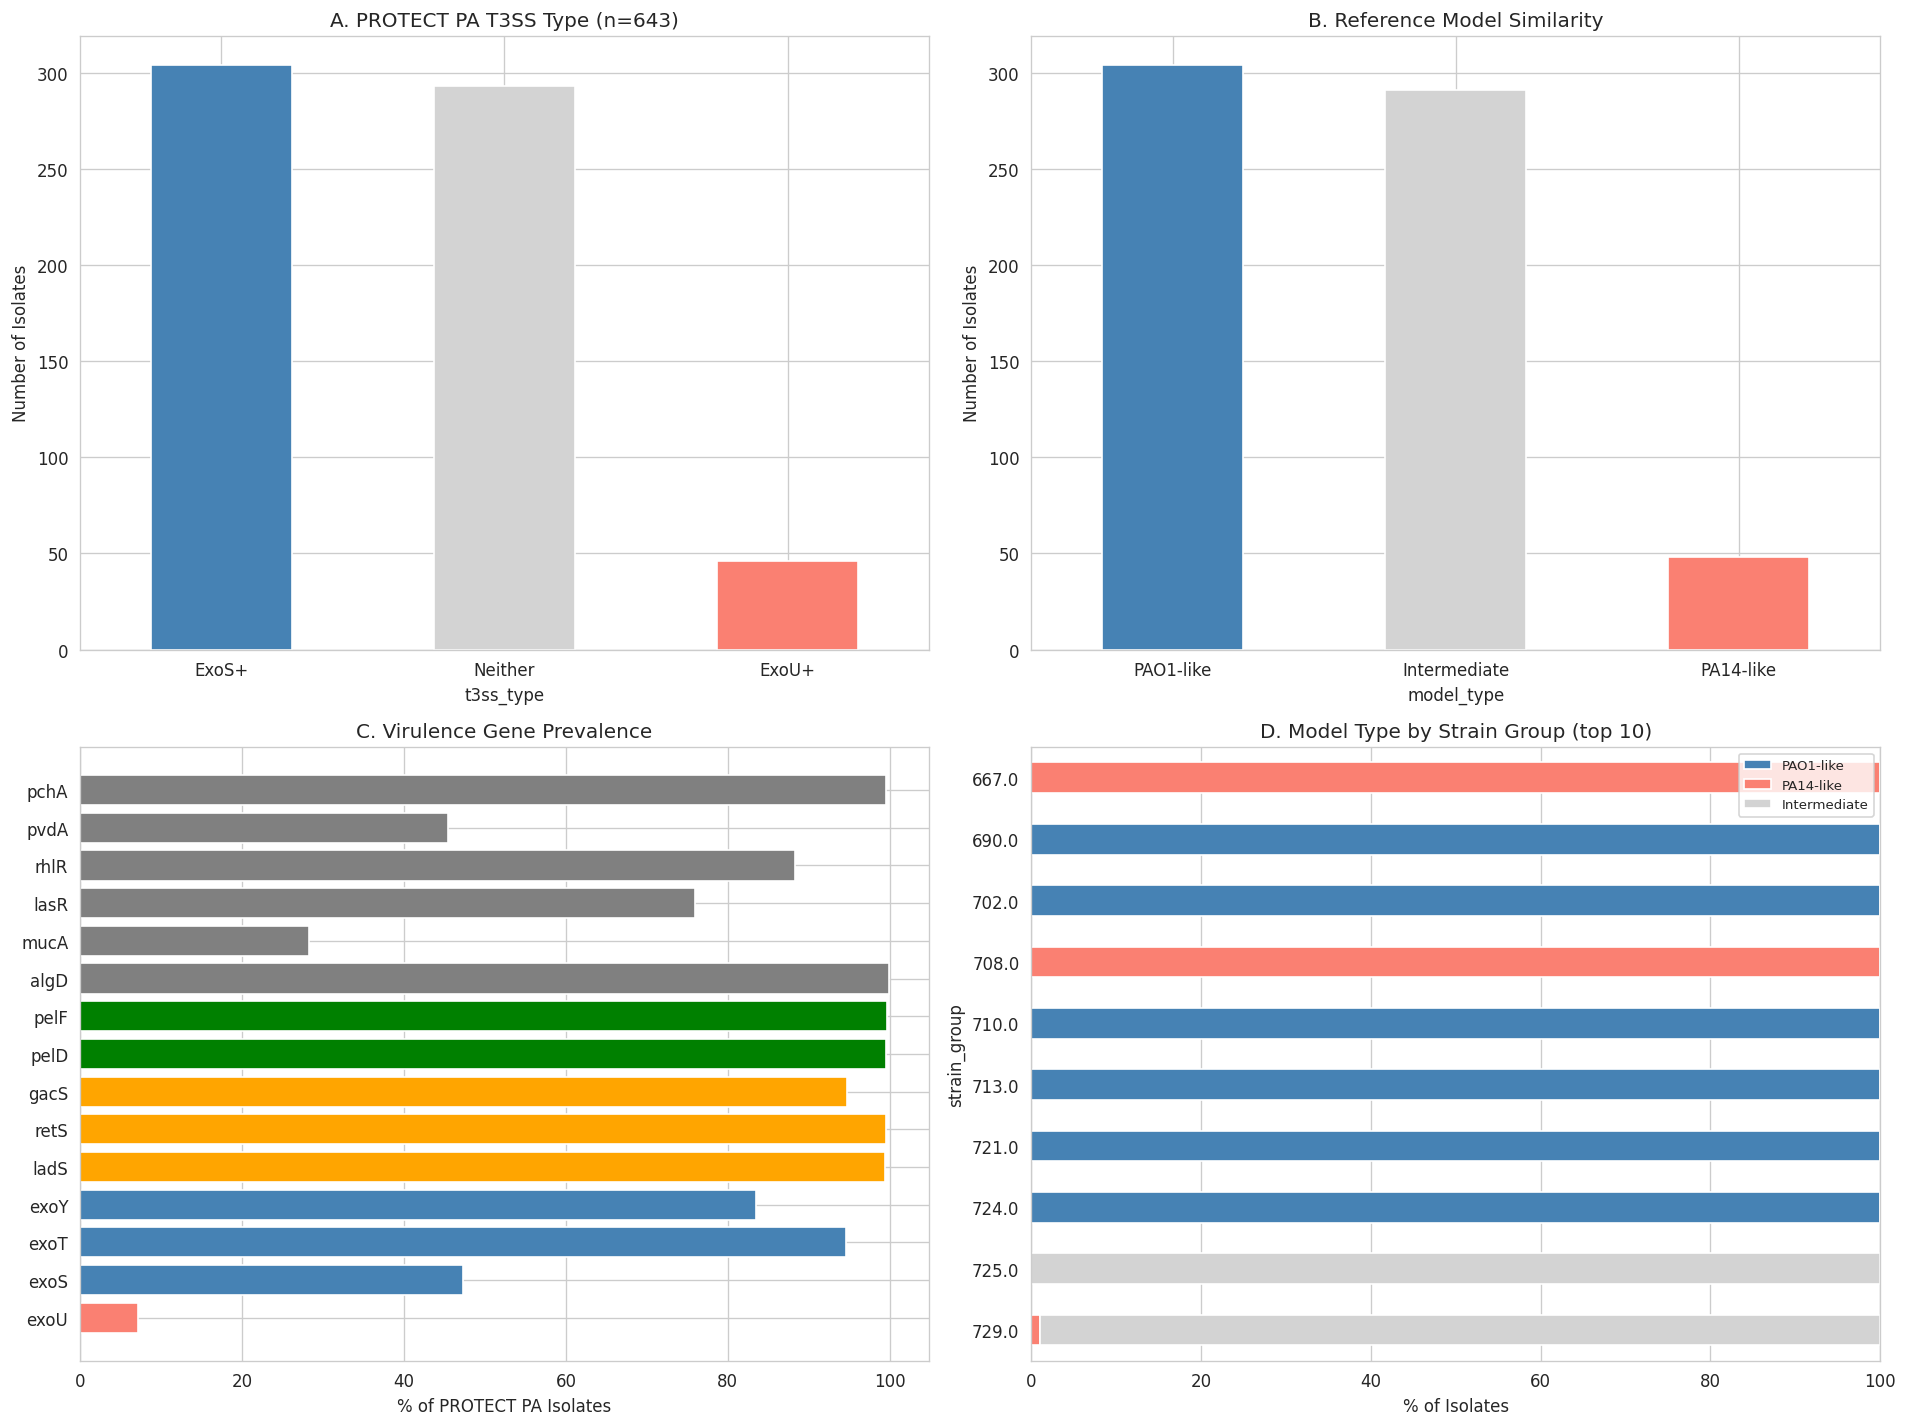

In [5]:
# Virulence profile summary figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A: T3SS type
ax = axes[0, 0]
t3ss_cts = vir_presence.t3ss_type.value_counts()
colors_t3ss = {'ExoS+': 'steelblue', 'ExoU+': 'salmon', 'ExoU+ExoS+': 'purple', 'Neither': 'lightgrey'}
t3ss_cts.plot.bar(ax=ax, color=[colors_t3ss.get(t, 'grey') for t in t3ss_cts.index])
ax.set_ylabel('Number of Isolates'); ax.set_title(f'A. PROTECT PA T3SS Type (n={len(vir_presence)})')
plt.sca(ax); plt.xticks(rotation=0)

# B: Model similarity
ax = axes[0, 1]
model_cts = vir_presence.model_type.value_counts()
colors_model = {'PAO1-like': 'steelblue', 'PA14-like': 'salmon', 'Intermediate': 'lightgrey'}
model_cts.plot.bar(ax=ax, color=[colors_model.get(m, 'grey') for m in model_cts.index])
ax.set_ylabel('Number of Isolates'); ax.set_title('B. Reference Model Similarity')
plt.sca(ax); plt.xticks(rotation=0)

# C: Gene prevalence
ax = axes[1, 0]
key_genes = [g for g in ['exoU','exoS','exoT','exoY','ladS','retS','gacS',
             'pelD','pelF','algD','mucA','lasR','rhlR','pvdA','pchA']
             if g in vir_presence.columns]
gene_pcts = [(vir_presence[g].sum() / len(vir_presence) * 100) for g in key_genes]
colors_bar = []
for g in key_genes:
    if 'exo' in g: colors_bar.append('salmon' if g == 'exoU' else 'steelblue')
    elif g.startswith(('pel','psl')): colors_bar.append('green')
    elif g in ['ladS','retS','gacS']: colors_bar.append('orange')
    else: colors_bar.append('grey')
ax.barh(range(len(key_genes)), gene_pcts, color=colors_bar)
ax.set_yticks(range(len(key_genes))); ax.set_yticklabels(key_genes)
ax.set_xlabel('% of PROTECT PA Isolates'); ax.set_title('C. Virulence Gene Prevalence')

# D: Model type by strain group
ax = axes[1, 1]
if 'strain_group' in asma_profiles.columns and asma_profiles.strain_group.notna().sum() > 5:
    sg_model = pd.crosstab(asma_profiles.strain_group.fillna('?'),
                           asma_profiles.model_type.fillna('Unknown'), normalize='index') * 100
    top_sg = asma_profiles.strain_group.value_counts().head(10).index
    sg_plot = sg_model.loc[[s for s in top_sg if s in sg_model.index]]
    cols = [c for c in ['PAO1-like','PA14-like','Intermediate'] if c in sg_plot.columns]
    sg_plot[cols].plot.barh(stacked=True, ax=ax, color=[colors_model.get(c, 'grey') for c in cols])
    ax.set_xlabel('% of Isolates'); ax.set_title('D. Model Type by Strain Group (top 10)')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Strain group data\nunavailable', ha='center', va='center', fontsize=12)
    ax.set_title('D. Model Type by Strain Group')

plt.tight_layout()
plt.savefig(FIGS / '14_asma_virulence_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Gene Content Phylogenetic Tree

Build a tree from gene cluster presence/absence across:
- All PROTECT PA representative genomes (one per strain group)
- PAO1 and PA14 reference strains
- ~150 sampled lung/airway PA from the pangenome

Gene content trees capture accessory genome variation — the biology that
distinguishes PAO1-like from PA14-like strains.

In [6]:
# Step 1: Identify genomes for the tree
# PROTECT: use representative isolates (one per strain group) + all unique T3SS types
protect_reps = pa_iso[pa_iso.representative == 'Yes']
print(f'PROTECT representative isolates: {len(protect_reps)}')

# Map PROTECT accessions to pangenome genome IDs
# dim_isolate has closest_genome_reference (GCF_/GCA_ accession)
protect_accessions = protect_reps.closest_genome_reference.dropna().unique()
print(f'Unique reference accessions: {len(protect_accessions)}')

# Convert to pangenome format (add RS_/GB_ prefix)
protect_pan_ids = []
for acc in protect_accessions:
    if acc.startswith('GCF_'):
        protect_pan_ids.append(f'RS_{acc}')
    elif acc.startswith('GCA_'):
        protect_pan_ids.append(f'GB_{acc}')
    else:
        protect_pan_ids.append(acc)

# Sample lung/airway PA from pangenome (beyond PROTECT)
pa_env = pd.read_csv(DATA / 'pa_genome_sources.tsv', sep='\t')
lung_pa = pa_env[pa_env.category.isin(['CF patient', 'Lung/Respiratory'])]
# Sample up to 150 lung PA genomes
np.random.seed(42)
n_sample = min(150, len(lung_pa))
sampled_lung = lung_pa.sample(n_sample, random_state=42)
sampled_lung_ids = sampled_lung.genome_id.tolist()

# Combine all genome IDs for the tree
tree_ids = list(set(protect_pan_ids + sampled_lung_ids + [PAO1_ID, PA14_ID]))
print(f'Total genomes for tree: {len(tree_ids)}')
print(f'  PROTECT reps: {len(protect_pan_ids)}')
print(f'  Sampled lung: {n_sample}')
print(f'  References: 2 (PAO1, PA14)')

PROTECT representative isolates: 15
Unique reference accessions: 1
Total genomes for tree: 153
  PROTECT reps: 1
  Sampled lung: 150
  References: 2 (PAO1, PA14)


In [7]:
# Step 2: Get gene cluster assignments for all tree genomes
# Query gene_genecluster_junction for each genome
tree_id_sql = "','".join(tree_ids)

print('Querying gene cluster assignments (this may take a few minutes)...')
# Get all gene-to-cluster mappings for our genomes
gene_clusters = spark.sql(f"""
    SELECT g.genome_id, ggj.gene_cluster_id
    FROM kbase_ke_pangenome.gene g
    JOIN kbase_ke_pangenome.gene_genecluster_junction ggj ON g.gene_id = ggj.gene_id
    WHERE g.genome_id IN ('{tree_id_sql}')
""").toPandas()

print(f'Gene-cluster mappings: {len(gene_clusters)} rows')
print(f'Genomes found: {gene_clusters.genome_id.nunique()}/{len(tree_ids)}')
print(f'Gene clusters: {gene_clusters.gene_cluster_id.nunique()}')

# Filter to PA gene clusters only (from the PA clade)
pa_clusters = spark.sql(f"""
    SELECT gene_cluster_id FROM kbase_ke_pangenome.gene_cluster
    WHERE gtdb_species_clade_id = '{PA_CLADE}'
""").toPandas()

gene_clusters_pa = gene_clusters[gene_clusters.gene_cluster_id.isin(pa_clusters.gene_cluster_id)]
print(f'After PA clade filter: {len(gene_clusters_pa)} mappings, {gene_clusters_pa.gene_cluster_id.nunique()} clusters')

Querying gene cluster assignments (this may take a few minutes)...


Gene-cluster mappings: 937331 rows
Genomes found: 153/153
Gene clusters: 34037


After PA clade filter: 937331 mappings, 34037 clusters


In [8]:
# Step 3: Build presence/absence matrix
# Pivot: genomes x gene_clusters (binary)
gc_presence = gene_clusters_pa.groupby(['genome_id', 'gene_cluster_id']).size().unstack(fill_value=0)
gc_presence = (gc_presence > 0).astype(int)
print(f'Gene content matrix: {gc_presence.shape[0]} genomes x {gc_presence.shape[1]} gene clusters')

# Filter to accessory gene clusters (variable across genomes) for better tree resolution
# Core genes (present in >95% of genomes) don't contribute to tree topology
cluster_freq = gc_presence.mean(axis=0)
accessory_mask = (cluster_freq > 0.05) & (cluster_freq < 0.95)
gc_accessory = gc_presence.loc[:, accessory_mask]
print(f'Accessory gene clusters (5-95% frequency): {gc_accessory.shape[1]}')

# Compute Jaccard distance matrix
print('Computing Jaccard distances...')
dist_matrix = pdist(gc_accessory.values, metric='jaccard')
dist_square = squareform(dist_matrix)
print(f'Distance matrix: {dist_square.shape[0]}x{dist_square.shape[1]}')
print(f'Mean distance: {dist_matrix.mean():.3f}, range: [{dist_matrix.min():.3f}, {dist_matrix.max():.3f}]')

Gene content matrix: 153 genomes x 34037 gene clusters
Accessory gene clusters (5-95% frequency): 3730
Computing Jaccard distances...
Distance matrix: 153x153
Mean distance: 0.615, range: [0.009, 0.842]


In [9]:
# Step 4: Build neighbor-joining tree using scipy hierarchical clustering
# Ward's method on Jaccard distances
print('Building hierarchical tree...')
Z = linkage(dist_matrix, method='average')  # UPGMA — standard for distance matrices

# Convert to Newick format for Bio.Phylo
from scipy.cluster.hierarchy import to_tree

def linkage_to_newick(Z, labels):
    """Convert scipy linkage matrix to Newick string."""
    tree = to_tree(Z, rd=False)
    def build_newick(node, labels):
        if node.is_leaf():
            return f'{labels[node.id]}:{node.dist:.6f}'
        left = build_newick(node.get_left(), labels)
        right = build_newick(node.get_right(), labels)
        return f'({left},{right}):{node.dist:.6f}'
    return build_newick(tree, labels) + ';'

labels = gc_accessory.index.tolist()
newick_str = linkage_to_newick(Z, labels)

# Parse with Bio.Phylo
tree = Phylo.read(StringIO(newick_str), 'newick')
print(f'Tree built: {tree.count_terminals()} leaves')

# Save Newick
with open(DATA / 'pa_gene_content_tree.nwk', 'w') as f:
    f.write(newick_str)
print(f'Saved: pa_gene_content_tree.nwk')

Building hierarchical tree...
Tree built: 153 leaves
Saved: pa_gene_content_tree.nwk


## 4. Annotated Circular Tree with pycirclize

Visualize the gene content tree as a circular phylogram with annotation rings
for virulence features, patient data, and isolation source.

In [10]:
# Build annotation table for all tree genomes
tree_genomes = gc_accessory.index.tolist()

# Load NB13 virulence data
vir_nb13 = pd.read_csv(DATA / 'pa_virulence_systems.tsv', sep='\t', index_col=0)

annot = pd.DataFrame(index=tree_genomes)

# Source classification
env_map = pa_env.set_index('genome_id')['category'].to_dict()
annot['source'] = annot.index.map(env_map).fillna('Unknown')

# Mark PROTECT and references
protect_set = set(protect_pan_ids)
annot['is_protect'] = annot.index.isin(protect_set)
annot['is_reference'] = annot.index.isin([PAO1_ID, PA14_ID])
if PAO1_ID in annot.index:
    annot.loc[PAO1_ID, 'source'] = 'Reference (PAO1)'
if PA14_ID in annot.index:
    annot.loc[PA14_ID, 'source'] = 'Reference (PA14)'

# T3SS and biofilm from NB13
annot['t3ss_type'] = annot.index.map(
    vir_nb13['t3ss_type'].to_dict() if 't3ss_type' in vir_nb13.columns else {}
).fillna('Unknown')
annot['biofilm_type'] = annot.index.map(
    vir_nb13['biofilm_type'].to_dict() if 'biofilm_type' in vir_nb13.columns else {}
).fillna('Unknown')

# Strain group for PROTECT reps
acc_to_sg = {}
for _, row in protect_reps.iterrows():
    acc = row.closest_genome_reference
    if pd.notna(acc):
        pan_id = f'RS_{acc}' if str(acc).startswith('GCF_') else f'GB_{acc}'
        acc_to_sg[pan_id] = str(row.strain_group) if pd.notna(row.strain_group) else ''
annot['strain_group'] = annot.index.map(acc_to_sg).fillna('')

print(f'Annotation table: {len(annot)} genomes')
print(f'Source: {annot.source.value_counts().to_string()}')
print(f'T3SS: {annot.t3ss_type.value_counts().to_string()}')
print(f'PROTECT: {annot.is_protect.sum()}, References: {annot.is_reference.sum()}')

Annotation table: 153 genomes
Source: source
Lung/Respiratory    128
CF patient           22
Reference (PAO1)      1
Reference (PA14)      1
Other                 1
T3SS: t3ss_type
ExoS+         124
ExoU+          27
Neither         1
ExoU+ExoS+      1
PROTECT: 1, References: 2


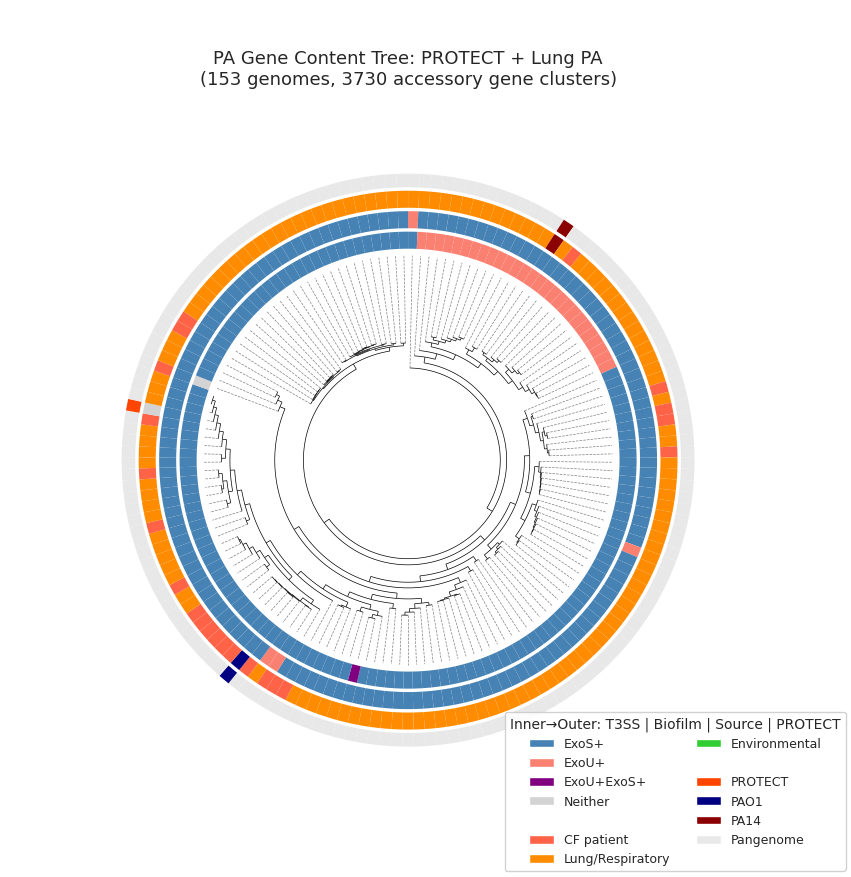

Saved: 14_pa_phylogenetic_tree.png


In [11]:
# Circular tree visualization with pycirclize
from pycirclize import Circos
from matplotlib.patches import Patch

# Read tree
tree = Phylo.read(StringIO(newick_str), 'newick')
leaf_names = [leaf.name for leaf in tree.get_terminals()]

# Color maps
t3ss_cmap = {'ExoS+': '#4682B4', 'ExoU+': '#FA8072', 'ExoU+ExoS+': '#800080', 'Neither': '#D3D3D3', 'Unknown': '#F5F5F5'}
bf_cmap = {'Pel+Psl': '#4682B4', 'Pel+Psl+ (PAO1-like)': '#4682B4', 'Pel-only': '#FA8072',
           'Pel-only (PA14-like)': '#FA8072', 'Psl-only': '#90EE90', 'Minimal': '#D3D3D3', 'Unknown': '#F5F5F5'}
src_cmap = {'CF patient': '#FF6347', 'Lung/Respiratory': '#FF8C00', 'Upper Airway': '#FFD700',
            'Other Clinical': '#87CEEB', 'Environmental': '#32CD32', 'Other': '#D3D3D3',
            'Unknown': '#F5F5F5', 'Reference (PAO1)': '#000080', 'Reference (PA14)': '#8B0000'}

# Build color arrays for each ring
def get_color(name, col, cmap, default='#F5F5F5'):
    if name in annot.index:
        val = annot.loc[name, col]
        return cmap.get(val, default)
    return default

ring1 = [get_color(n, 't3ss_type', t3ss_cmap) for n in leaf_names]
ring2 = [get_color(n, 'biofilm_type', bf_cmap) for n in leaf_names]
ring3 = [get_color(n, 'source', src_cmap) for n in leaf_names]
ring4 = ['#FF4500' if (n in annot.index and annot.loc[n, 'is_protect']) else
         '#000080' if n == PAO1_ID else '#8B0000' if n == PA14_ID else '#E8E8E8'
         for n in leaf_names]

# Initialize circos from tree — returns (Circos, TreeViz)
circos, tv = Circos.initialize_from_tree(
    tree, r_lim=(25, 60), leaf_label_size=0
)

# Add annotation rings on the single sector
sector = circos.sectors[0]

# Ring 1: T3SS (inner)
t1 = sector.add_track((62, 67))
for i, c in enumerate(ring1):
    t1.rect(i, i+1, fc=c, ec='none')

# Ring 2: Biofilm
t2 = sector.add_track((68, 73))
for i, c in enumerate(ring2):
    t2.rect(i, i+1, fc=c, ec='none')

# Ring 3: Source
t3 = sector.add_track((74, 79))
for i, c in enumerate(ring3):
    t3.rect(i, i+1, fc=c, ec='none')

# Ring 4: PROTECT/Reference
t4 = sector.add_track((80, 84))
for i, c in enumerate(ring4):
    t4.rect(i, i+1, fc=c, ec='none')

fig = circos.plotfig()

# Legend
legend_elements = [
    Patch(fc='#4682B4', label='ExoS+'), Patch(fc='#FA8072', label='ExoU+'),
    Patch(fc='#800080', label='ExoU+ExoS+'), Patch(fc='#D3D3D3', label='Neither'),
    Patch(fc='white', ec='white', label=''),
    Patch(fc='#FF6347', label='CF patient'), Patch(fc='#FF8C00', label='Lung/Respiratory'),
    Patch(fc='#32CD32', label='Environmental'),
    Patch(fc='white', ec='white', label=''),
    Patch(fc='#FF4500', label='PROTECT'), Patch(fc='#000080', label='PAO1'),
    Patch(fc='#8B0000', label='PA14'), Patch(fc='#E8E8E8', label='Pangenome'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9, ncol=2,
           title='Inner→Outer: T3SS | Biofilm | Source | PROTECT',
           title_fontsize=10, framealpha=0.9)

plt.suptitle(f'PA Gene Content Tree: PROTECT + Lung PA\n'
             f'({len(leaf_names)} genomes, {gc_accessory.shape[1]} accessory gene clusters)',
             fontsize=13, y=0.98)

plt.savefig(FIGS / '14_pa_phylogenetic_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 14_pa_phylogenetic_tree.png')

## 5. Summary

In [12]:
# Save profiles
profile_out = vir_presence[['t3ss_type','biofilm_type','model_type','pel_count','psl_count'] +
    [c for c in vir_presence.columns if c in virulence_genes]].copy()
profile_out.to_csv(DATA / 'asma_pa_virulence_profiles.tsv', sep='\t')
annot.to_csv(DATA / 'pa_tree_annotations.tsv', sep='\t')

print('=' * 70)
print('NB14 SUMMARY: ASMA PA VIRULENCE PROFILING & PHYLOGENETIC TREE')
print('=' * 70)

print(f'\n1. PROTECT PA VIRULENCE PROFILES ({len(vir_presence)} genomes)')
print(f'   T3SS: ExoS+ {(vir_presence.t3ss_type=="ExoS+").sum()}, '
      f'ExoU+ {(vir_presence.t3ss_type=="ExoU+").sum()}, '
      f'Neither {(vir_presence.t3ss_type=="Neither").sum()}')
print(f'   Model: PAO1-like {(vir_presence.model_type=="PAO1-like").sum()}, '
      f'PA14-like {(vir_presence.model_type=="PA14-like").sum()}, '
      f'Intermediate {(vir_presence.model_type=="Intermediate").sum()}')

print(f'\n2. PHYLOGENETIC TREE')
print(f'   Total genomes: {len(tree_genomes)}')
print(f'   Accessory gene clusters: {gc_accessory.shape[1]}')
print(f'   PROTECT representatives: {annot.is_protect.sum()}')
print(f'   Pangenome lung/airway: {n_sample}')
print(f'   Reference strains: PAO1 + PA14')

print(f'\n3. KEY OBSERVATION')
n_pao1like = (vir_presence.model_type == 'PAO1-like').sum()
n_pa14like = (vir_presence.model_type == 'PA14-like').sum()
print(f'   {n_pao1like/(n_pao1like+n_pa14like)*100:.0f}% of classifiable PROTECT PA are PAO1-like')
print(f'   PA14 is a poor reference for CF competitive exclusion assays')

print(f'\nFiles saved:')
print(f'  {DATA}/asma_pa_virulence_profiles.tsv')
print(f'  {DATA}/pa_tree_annotations.tsv')
print(f'  {DATA}/pa_gene_content_tree.nwk')
print(f'  {FIGS}/14_asma_virulence_profiles.png')
print(f'  {FIGS}/14_pa_phylogenetic_tree.png')

NB14 SUMMARY: ASMA PA VIRULENCE PROFILING & PHYLOGENETIC TREE

1. PROTECT PA VIRULENCE PROFILES (643 genomes)
   T3SS: ExoS+ 304, ExoU+ 46, Neither 293
   Model: PAO1-like 304, PA14-like 48, Intermediate 291

2. PHYLOGENETIC TREE
   Total genomes: 153
   Accessory gene clusters: 3730
   PROTECT representatives: 1
   Pangenome lung/airway: 150
   Reference strains: PAO1 + PA14

3. KEY OBSERVATION
   86% of classifiable PROTECT PA are PAO1-like
   PA14 is a poor reference for CF competitive exclusion assays

Files saved:
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/asma_pa_virulence_profiles.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pa_tree_annotations.tsv
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/data/pa_gene_content_tree.nwk
  /home/aparkin/BERIL-research-observatory/projects/cf_formulation_design/figures/14_asma_virulence_profiles.png
  /home/aparkin/BERIL-research-observatory/pr